In [1]:
import numpy as np
import pandas as pd

In [2]:
train_df= pd.read_csv('PubMed_20k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_20k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_20k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24293578,24293578_0_12,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,24293578,24293578_1_12,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,24293578,24293578_2_12,Outcome measures included pain reduction and i...,2,12,METHODS
3,24293578,24293578_3_12,Pain was assessed using the visual analog pain...,3,12,METHODS
4,24293578,24293578_4_12,Secondary outcome measures included the Wester...,4,12,METHODS


In [3]:
print(train_df.describe())
print(train_df.info())

        abstract_id    line_number    total_lines
count  1.800400e+05  180040.000000  180040.000000
mean   2.501496e+07       5.894568      12.789136
std    5.153296e+05       4.127672       3.236095
min    2.421977e+07       0.000000       4.000000
25%    2.458516e+07       3.000000      11.000000
50%    2.495697e+07       6.000000      12.000000
75%    2.539212e+07       9.000000      15.000000
max    2.652916e+07      30.000000      31.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180040 entries, 0 to 180039
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   abstract_id    180040 non-null  int64 
 1   line_id        180040 non-null  object
 2   abstract_text  180040 non-null  object
 3   line_number    180040 non-null  int64 
 4   total_lines    180040 non-null  int64 
 5   target         180040 non-null  object
dtypes: int64(3), object(3)
memory usage: 8.2+ MB
None


In [4]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  3.021200e+04  30212.000000  30212.000000
mean   2.502800e+07      5.930988     12.861975
std    5.098474e+05      4.142448      3.220353
min    2.421989e+07      0.000000      4.000000
25%    2.460663e+07      3.000000     11.000000
50%    2.498672e+07      6.000000     12.000000
75%    2.540678e+07      9.000000     15.000000
max    2.652158e+07     26.000000     27.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30212 entries, 0 to 30211
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30212 non-null  int64 
 1   line_id        30212 non-null  object
 2   abstract_text  30212 non-null  object
 3   line_number    30212 non-null  int64 
 4   total_lines    30212 non-null  int64 
 5   target         30212 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [5]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  3.013500e+04  30135.000000  30135.000000
mean   2.504292e+07      5.922980     12.845960
std    5.209988e+05      4.141561      3.232885
min    2.422001e+07      0.000000      4.000000
25%    2.461834e+07      3.000000     11.000000
50%    2.500021e+07      6.000000     12.000000
75%    2.542062e+07      9.000000     15.000000
max    2.652158e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30135 entries, 0 to 30134
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30135 non-null  int64 
 1   line_id        30135 non-null  object
 2   abstract_text  30135 non-null  object
 3   line_number    30135 non-null  int64 
 4   total_lines    30135 non-null  int64 
 5   target         30135 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [6]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
train_df.head()

,abstract_text,line_number,total_lines,target
0,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,Outcome measures included pain reduction and i...,2,12,METHODS
3,Pain was assessed using the visual analog pain...,3,12,METHODS
4,Secondary outcome measures included the Wester...,4,12,METHODS


In [7]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [8]:
train_sentences = train_df["abstract_text"].tolist()
train_labels = train_df["target"].tolist()

val_sentences = dev_df["abstract_text"].tolist()
val_labels = dev_df["target"].tolist()

In [9]:
print(len(train_sentences))
print(len(train_labels))
print(len(val_sentences))
print(len(val_labels))

180040
180040
30212
30212


## Step 3: Encode Labels

In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)

train_labels_onehot = to_categorical(train_labels_encoded)
val_labels_onehot = to_categorical(val_labels_encoded)

## Step 4: Tokenization

In [12]:
max_vocab = 20000
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)

## Step 5: Padding


In [13]:
max_length = 55
train_padded = pad_sequences(train_sequences, maxlen= max_length, padding= "post")
val_padded = pad_sequences(val_sequences, maxlen= max_length, padding = "post")

## Build The LSTM Model
### Simple LSTM Architecture

In [18]:
model = tf.keras.Sequential([layers.Embedding(input_dim = max_vocab, output_dim = 128, input_length = max_length),
                             layers.LSTM(128),
                             layers.Dense(64, activation = "relu"),
                             layers.Dense(5, activation = "softmax")])

In [20]:
## Comile Model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ["accuracy"])

In [21]:
# Training
history = model.fit(train_padded, train_labels_onehot,
                    validation_data=(val_padded, val_labels_onehot),
                    epochs = 5,
                    batch_size = 32)

Epoch 1/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 642s 113ms/step - accuracy: 0.7409 - loss: 0.6657 - val_accuracy: 0.8251 - val_loss: 0.4818
Epoch 2/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 780s 139ms/step - accuracy: 0.8430 - loss: 0.4307 - val_accuracy: 0.8314 - val_loss: 0.4595
Epoch 3/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 1038s 184ms/step - accuracy: 0.8732 - loss: 0.3519 - val_accuracy: 0.8298 - val_loss: 0.4706
Epoch 4/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 769s 137ms/step - accuracy: 0.9016 - loss: 0.2814 - val_accuracy: 0.8236 - val_loss: 0.5171
Epoch 5/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 606s 108ms/step - accuracy: 0.9236 - loss: 0.2223 - val_accuracy: 0.8134 - val_loss: 0.6110


In [22]:
# Get Prediction probabilitties
val_pred_probs = model.predict(val_padded)

945/945 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step


In [23]:
# Convert Predicted Probabilites to class index
val_pred_classes = np.argmax(val_pred_probs, axis = 1)

# Convert Truel labels from one-hot 
val_true_classes = np.argmax(val_labels_onehot, axis =1)

In [24]:
## Classification Report
from sklearn.metrics import classification_report
print(classification_report(val_true_classes,
                            val_pred_classes,
                            target_names = label_encoder.classes_))

              precision    recall  f1-score   support

  BACKGROUND       0.60      0.68      0.64      3449
 CONCLUSIONS       0.74      0.74      0.74      4582
     METHODS       0.89      0.90      0.90      9964
   OBJECTIVE       0.66      0.56      0.61      2376
     RESULTS       0.89      0.87      0.88      9841

    accuracy                           0.81     30212
   macro avg       0.76      0.75      0.75     30212
weighted avg       0.82      0.81      0.81     30212



In [25]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)

[[2350  382  188  504   25]
 [ 569 3371  122   63  457]
 [ 184   89 8994   98  599]
 [ 758  147  121 1330   20]
 [  67  588  640   17 8529]]


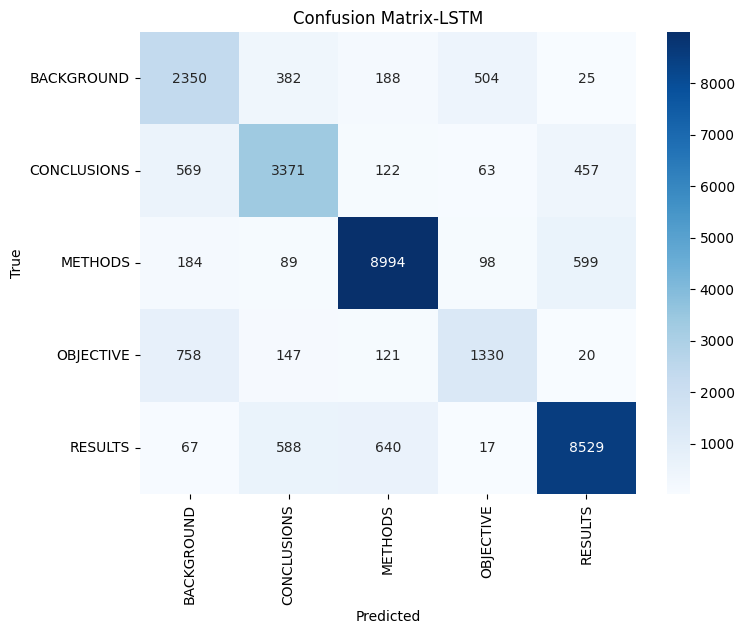

In [26]:
#visualize the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt="d", xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-LSTM")
plt.show()

In [28]:
## Class wise accuracy
class_accuracy = cm.diagonal()/cm.sum(axis=1)
for label, acc in zip(label_encoder.classes_, class_accuracy):
    print(f"{label}: {acc:3f}")

BACKGROUND: 0.681357
CONCLUSIONS: 0.735705
METHODS: 0.902650
OBJECTIVE: 0.559764
RESULTS: 0.866680


In [29]:
# Overall Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_true_classes, val_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.813385409770952


In [30]:
## Research-Level Evalauation 
from sklearn.metrics import f1_score

macro_f1 = f1_score(val_true_classes, val_pred_classes, average="macro")
weighted_f1 = f1_score(val_true_classes, val_pred_classes, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.7507181019355331
Weighted F1: 0.8136055532995042


## Using Bidirectional Model

In [60]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

In [62]:
train_sentences = train_df["abstract_text"].astype(str).values
val_sentences   = dev_df["abstract_text"].astype(str).values
test_sentences  = test_df["abstract_text"].astype(str).values

train_labels = train_df["target"].values
val_labels   = dev_df["target"].values
test_labels  = test_df["target"].values

In [63]:
label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded   = label_encoder.transform(val_labels)
test_labels_encoded  = label_encoder.transform(test_labels)

print(label_encoder.classes_)

['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']


In [64]:
max_vocab = 20000

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences   = tokenizer.texts_to_sequences(val_sentences)
test_sequences  = tokenizer.texts_to_sequences(test_sentences)

In [65]:
max_length = 55

train_padded = pad_sequences(train_sequences, maxlen=max_length, padding="post")
val_padded   = pad_sequences(val_sequences, maxlen=max_length, padding="post")
test_padded  = pad_sequences(test_sequences, maxlen=max_length, padding="post")

In [66]:
train_padded = np.array(train_padded, dtype=np.int32)
val_padded   = np.array(val_padded, dtype=np.int32)
test_padded  = np.array(test_padded, dtype=np.int32)

train_labels_encoded = np.array(train_labels_encoded, dtype=np.int32)
val_labels_encoded   = np.array(val_labels_encoded, dtype=np.int32)
test_labels_encoded  = np.array(test_labels_encoded, dtype=np.int32)

In [78]:
model = tf.keras.Sequential([
    
    layers.Embedding(
        input_dim=max_vocab,
        output_dim=128,
        input_length=max_length
    ),
    
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    
    layers.Dropout(0.5),
    
    layers.Dense(64, activation="relu"),
    
    layers.Dense(5, activation="softmax")
])


C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [79]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

In [80]:
history = model.fit(
    train_padded,
    train_labels_encoded,
    validation_data=(val_padded, val_labels_encoded),
    epochs=5,
    batch_size=32
)

Epoch 1/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 743s 129ms/step - accuracy: 0.7880 - loss: 0.5767 - val_accuracy: 0.8161 - val_loss: 0.4930
Epoch 2/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 718s 128ms/step - accuracy: 0.8462 - loss: 0.4291 - val_accuracy: 0.8321 - val_loss: 0.4570
Epoch 3/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 735s 131ms/step - accuracy: 0.8720 - loss: 0.3595 - val_accuracy: 0.8349 - val_loss: 0.4588
Epoch 4/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 717s 127ms/step - accuracy: 0.8955 - loss: 0.2951 - val_accuracy: 0.8294 - val_loss: 0.5064
Epoch 5/5
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 1229s 218ms/step - accuracy: 0.9158 - loss: 0.2395 - val_accuracy: 0.8194 - val_loss: 0.5689


In [81]:
# Get Prediction probabilitties
val_pred_probs = model.predict(val_padded)

945/945 ━━━━━━━━━━━━━━━━━━━━ 108s 113ms/step


In [82]:
# Convert Predicted Probabilites to class index
val_pred_classes = np.argmax(val_pred_probs, axis = 1)

# Convert Truel labels from one-hot 
val_true_classes = np.argmax(val_labels_onehot, axis =1)

In [83]:
## Classification Report
from sklearn.metrics import classification_report
print(classification_report(val_true_classes,
                            val_pred_classes,
                            target_names = label_encoder.classes_))

              precision    recall  f1-score   support

  BACKGROUND       0.58      0.75      0.66      3449
 CONCLUSIONS       0.77      0.70      0.73      4582
     METHODS       0.89      0.93      0.91      9964
   OBJECTIVE       0.70      0.50      0.58      2376
     RESULTS       0.89      0.87      0.88      9841

    accuracy                           0.82     30212
   macro avg       0.77      0.75      0.75     30212
weighted avg       0.82      0.82      0.82     30212



In [84]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)

[[2590  288  175  369   27]
 [ 646 3185  123   60  568]
 [ 208   67 9228   58  403]
 [ 949  104  123 1180   20]
 [  57  468  736    8 8572]]


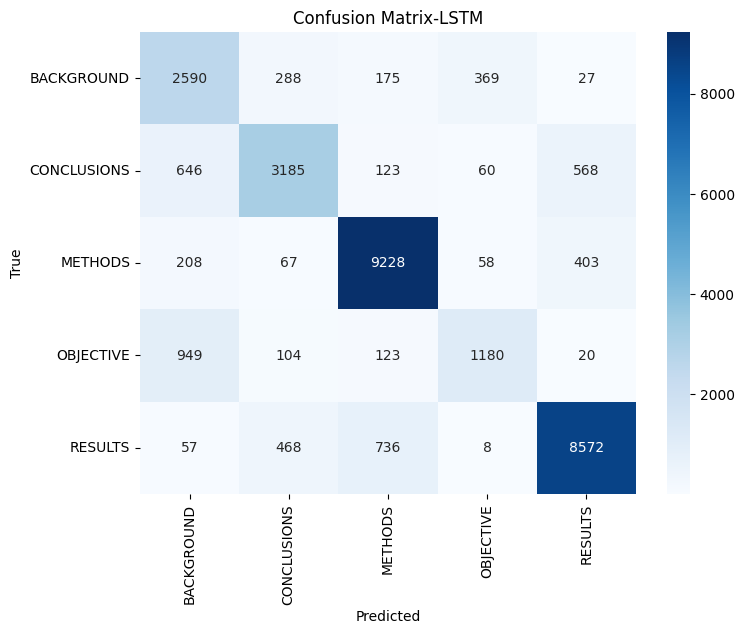

In [85]:
#visualize the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt="d", xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-LSTM")
plt.show()

In [86]:
## Class wise accuracy
class_accuracy = cm.diagonal()/cm.sum(axis=1)
for label, acc in zip(label_encoder.classes_, class_accuracy):
    print(f"{label}: {acc:3f}")

BACKGROUND: 0.750942
CONCLUSIONS: 0.695111
METHODS: 0.926134
OBJECTIVE: 0.496633
RESULTS: 0.871050


In [87]:
# Overall Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_true_classes, val_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.8193764067258044


In [88]:
## Research-Level Evalauation 
from sklearn.metrics import f1_score

macro_f1 = f1_score(val_true_classes, val_pred_classes, average="macro")
weighted_f1 = f1_score(val_true_classes, val_pred_classes, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.7520630841131821
Weighted F1: 0.818316131959199
